In [1]:
# ============================================================
# NOTEBOOK 3 — CLUSTERING
# Segmenting Tournaments by Digital vs Physical Impact
# Business Objective: Decide WHERE to invest marketing budget
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [2]:
# ============================================================
# 1. DATA LOADING & MERGING
# ============================================================
top_tours = pd.read_csv('../data/clean_top_tournaments.csv')
social    = pd.read_csv('../data/clean_tournaments_social.csv')

top_tours['match_key'] = top_tours['tournament_name'].str[:15].str.lower().str.strip()
social['match_key']    = social['tournament_name'].str[:15].str.lower().str.strip()

df = top_tours.merge(social, on='match_key', how='left', suffixes=('', '_social'))

print(f"Merged dataset shape: {df.shape}")
df.head()

Merged dataset shape: (31, 27)


,tournament_id,tournament_name,year,location,total_viewers_millions,peak_viewers_thousands,avg_viewers_thousands,tv_channels,digital_platforms,ticket_revenue_eur,...,match_key,tournament_name_social,instagram_posts,instagram_reach_millions,twitter_mentions,hashtag_uses,facebook_engagement,youtube_views_millions,tiktok_videos_millions,engagement_rate_percent
0,WPT001,World Padel Tour Master Final,2023,Barcelona,12.5,2100,850,Eurosport;Movistar+,WPT TV;YouTube,2100000,...,world padel tou,World Padel Tour Final,45200.0,18.7,89400.0,125000.0,89200.0,45.2,12.3,4.8
1,WPT002,Madrid Master,2024,Madrid,9.8,1800,720,DAZN;TVE,WPT TV,1850000,...,madrid master,Madrid Master,38700.0,15.2,72100.0,98700.0,76500.0,38.7,9.8,4.2
2,PPT001,Premier Padel Riyadh,2024,Riyadh,15.2,2800,1100,beIN Sports,WPT TV;YouTube,3200000,...,premier padel r,Premier Padel Riyadh,52100.0,22.3,95600.0,145000.0,112000.0,52.1,15.2,5.1
3,WPT003,Estrella Damm Master,2023,Valencia,8.3,1500,650,Movistar+,YouTube,1650000,...,estrella damm m,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,PPT002,Premier Padel Mexico,2023,Mexico City,11.3,2200,890,ESPN,WPT TV,1950000,...,premier padel m,Premier Padel Mexico,41200.0,16.8,78200.0,105000.0,87200.0,41.2,10.3,4.5


In [5]:
# ============================================================
# 2. FEATURE ENGINEERING — DIGITAL vs PHYSICAL AXES
# ============================================================

# Fill NaN in source columns FIRST
social_cols = ['instagram_reach_millions', 'youtube_views_millions',
               'tiktok_videos_millions', 'engagement_rate_percent']
for col in social_cols:
    df[col] = df[col].fillna(0)

# ── PHYSICAL IMPACT AXIS ──────────────────────────────────
df['physical_score'] = (
    (df['stadium_attendance'] / df['stadium_capacity']) * 40 +
    (df['stadium_capacity']   / df['stadium_capacity'].max()) * 30 +
    (df['prize_money_eur']    / df['prize_money_eur'].max()) * 20 +
    (df['ticket_revenue_eur'] / df['ticket_revenue_eur'].max()) * 10
)

# ── DIGITAL IMPACT AXIS ───────────────────────────────────
df['digital_score'] = (
    (df['instagram_reach_millions'] / df['instagram_reach_millions'].max()) * 25 +
    (df['youtube_views_millions']   / df['youtube_views_millions'].max())   * 25 +
    (df['tiktok_videos_millions']   / df['tiktok_videos_millions'].max())   * 20 +
    (df['total_viewers_millions']   / df['total_viewers_millions'].max())   * 20 +
    (df['engagement_rate_percent']  / df['engagement_rate_percent'].max())  * 10
)

# ── BROADCAST AXIS ────────────────────────────────────────
df['broadcast_score'] = (
    (df['tv_channels_count']      / df['tv_channels_count'].max())      * 50 +
    (df['peak_viewers_thousands'] / df['peak_viewers_thousands'].max()) * 50
)

# Normalise to 0-100
for col in ['physical_score', 'digital_score', 'broadcast_score']:
    df[col] = (df[col] - df[col].min()) / (df[col].max() - df[col].min()) * 100

# ── CRITICAL FIX: drop any remaining NaN rows ─────────────
cluster_features = ['physical_score', 'digital_score', 'broadcast_score']
df = df.dropna(subset=cluster_features).reset_index(drop=True)

print(f"Rows after NaN drop: {len(df)}")
print("\nNaN check:")
print(df[cluster_features].isna().sum())
print("\nScore statistics:")
print(df[cluster_features].describe().round(2))

X = df[cluster_features]
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\n✅ X_scaled shape: {X_scaled.shape}  — no NaN, ready for clustering")

Rows after NaN drop: 31

NaN check:
physical_score     0
digital_score      0
broadcast_score    0
dtype: int64

Score statistics:
       physical_score  digital_score  broadcast_score
count           31.00          31.00            31.00
mean            43.19          53.28            36.64
std             27.57          21.34            27.94
min              0.00           0.00             0.00
25%             20.25          37.51            11.07
50%             38.62          50.52            36.24
75%             68.11          67.64            52.18
max            100.00         100.00           100.00

✅ X_scaled shape: (31, 3)  — no NaN, ready for clustering


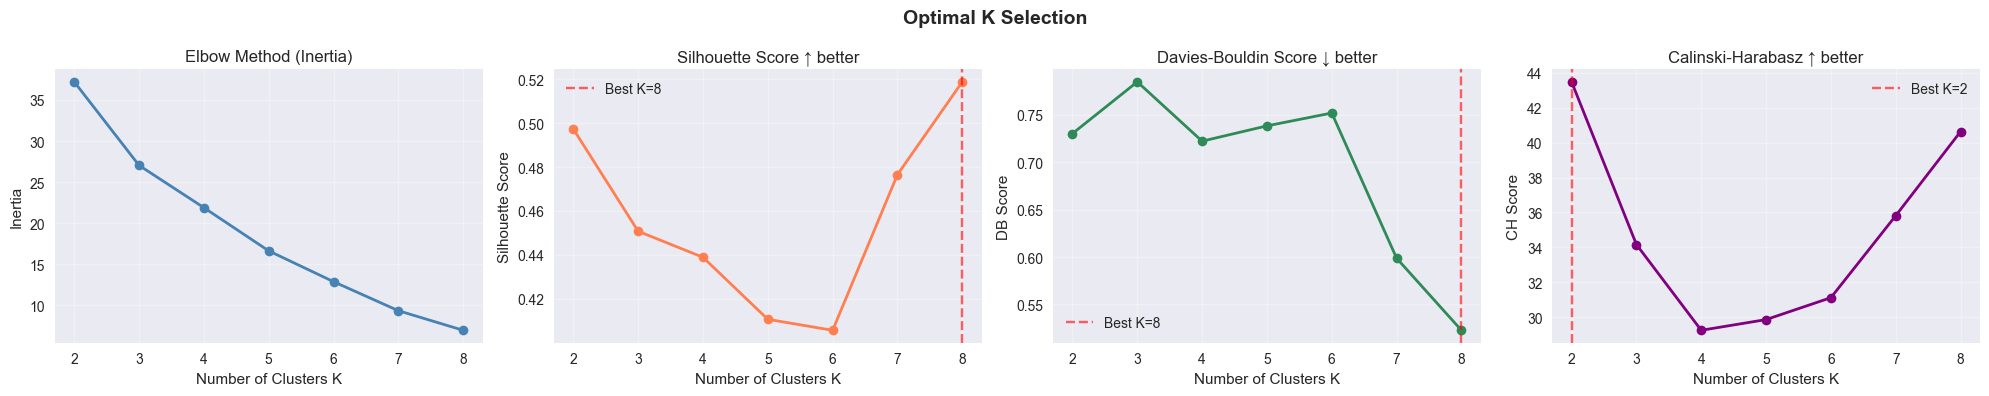


Best K by Silhouette:        K=8 (score=0.5187)
Best K by Davies-Bouldin:    K=8  (score=0.5227)
Best K by Calinski-Harabasz: K=2  (score=43.4887)

✅ Selected K = 8


In [7]:
# ============================================================
# 3. FINDING OPTIMAL NUMBER OF CLUSTERS
# ============================================================
k_range = range(2, 9)

inertias    = []
silhouettes = []
db_scores   = []
ch_scores   = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)  # no n_jobs here anyway
    labels = km.fit_predict(X_scaled)

    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle('Optimal K Selection', fontsize=14, fontweight='bold')

axes[0].plot(list(k_range), inertias, 'o-', color='steelblue', linewidth=2)
axes[0].set_title('Elbow Method (Inertia)')
axes[0].set_xlabel('Number of Clusters K')
axes[0].set_ylabel('Inertia')
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(k_range), silhouettes, 'o-', color='coral', linewidth=2)
axes[1].set_title('Silhouette Score ↑ better')
axes[1].set_xlabel('Number of Clusters K')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)

axes[2].plot(list(k_range), db_scores, 'o-', color='seagreen', linewidth=2)
axes[2].set_title('Davies-Bouldin Score ↓ better')
axes[2].set_xlabel('Number of Clusters K')
axes[2].set_ylabel('DB Score')
axes[2].grid(True, alpha=0.3)

axes[3].plot(list(k_range), ch_scores, 'o-', color='purple', linewidth=2)
axes[3].set_title('Calinski-Harabasz ↑ better')
axes[3].set_xlabel('Number of Clusters K')
axes[3].set_ylabel('CH Score')
axes[3].grid(True, alpha=0.3)

# Mark best K on each
best_sil_k = list(k_range)[np.argmax(silhouettes)]
best_db_k  = list(k_range)[np.argmin(db_scores)]
best_ch_k  = list(k_range)[np.argmax(ch_scores)]

for ax, best_k, scores in zip(axes[1:], [best_sil_k, best_db_k, best_ch_k],
                               [silhouettes, db_scores, ch_scores]):
    idx = list(k_range).index(best_k)
    ax.axvline(x=best_k, color='red', linestyle='--', alpha=0.6, label=f'Best K={best_k}')
    ax.legend()

plt.tight_layout()
plt.savefig('../outputs/clustering_optimal_k.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nBest K by Silhouette:        K={best_sil_k} (score={max(silhouettes):.4f})")
print(f"Best K by Davies-Bouldin:    K={best_db_k}  (score={min(db_scores):.4f})")
print(f"Best K by Calinski-Harabasz: K={best_ch_k}  (score={max(ch_scores):.4f})")

OPTIMAL_K = best_sil_k   # primary criterion
print(f"\n✅ Selected K = {OPTIMAL_K}")

In [8]:
# ============================================================
# 4. MODEL EXPLANATION
# ============================================================
print(f"""
╔══════════════════════════════════════════════════════════════╗
║         ALGORITHM 1: K-MEANS CLUSTERING                     ║
╠══════════════════════════════════════════════════════════════╣
║ INTUITION:                                                   ║
║   Assigns each tournament to the nearest centroid.         ║
║   Iterates until centroids stabilize.                      ║
║                                                             ║
║ KEY PARAMETERS:                                             ║
║   - k: number of clusters (chosen via Silhouette)          ║
║   - n_init: number of random initialisations               ║
║                                                             ║
║ ASSUMPTIONS:                                                ║
║   - Spherical, roughly equal-size clusters                 ║
║   - Euclidean distance is meaningful → needs scaling       ║
║                                                             ║
║ LIMITATIONS:                                                ║
║   - Sensitive to outliers                                  ║
║   - Must specify K in advance                              ║
║                                                             ║
║ WHY CHOSEN:                                                 ║
║   - Simple, fast, interpretable centroids                  ║
║   - Centroid values = business profile of each segment     ║
╚══════════════════════════════════════════════════════════════╝

╔══════════════════════════════════════════════════════════════╗
║         ALGORITHM 2: HIERARCHICAL CLUSTERING                ║
╠══════════════════════════════════════════════════════════════╣
║ INTUITION:                                                   ║
║   Builds a tree of merges (dendrogram).                    ║
║   No need to specify K — cut the tree where needed.        ║
║                                                             ║
║ KEY PARAMETERS:                                             ║
║   - linkage: ward (minimizes within-cluster variance)      ║
║   - n_clusters: where to cut the dendrogram                ║
║                                                             ║
║ ASSUMPTIONS:                                                ║
║   - Hierarchical structure exists in the data              ║
║                                                             ║
║ LIMITATIONS:                                                ║
║   - Computationally expensive for large n                  ║
║   - Cannot re-assign once merged                           ║
║                                                             ║
║ WHY CHOSEN:                                                 ║
║   - Dendrogram reveals natural tournament groupings        ║
║   - Validates K-Means results from different angle         ║
║   - Ward linkage optimal for our scaled 3D feature space   ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║         ALGORITHM 1: K-MEANS CLUSTERING                     ║
╠══════════════════════════════════════════════════════════════╣
║ INTUITION:                                                   ║
║   Assigns each tournament to the nearest centroid.         ║
║   Iterates until centroids stabilize.                      ║
║                                                             ║
║ KEY PARAMETERS:                                             ║
║   - k: number of clusters (chosen via Silhouette)          ║
║   - n_init: number of random initialisations               ║
║                                                             ║
║ ASSUMPTIONS:                                                ║
║   - Spherical, roughly equal-size clusters                 ║
║   - Euclidean distance is meaningful → needs scaling       ║
║                                                             ║
║ LIMITATIONS:                            

In [9]:
# ============================================================
# 5. FIT BOTH CLUSTERING ALGORITHMS
# ============================================================

# K-Means
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df['cluster_kmeans'] = kmeans.fit_predict(X_scaled)

# Hierarchical (Ward)
hierarchical = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
df['cluster_hier'] = hierarchical.fit_predict(X_scaled)

# Evaluate both
sil_km   = silhouette_score(X_scaled, df['cluster_kmeans'])
sil_hier = silhouette_score(X_scaled, df['cluster_hier'])
db_km    = davies_bouldin_score(X_scaled, df['cluster_kmeans'])
db_hier  = davies_bouldin_score(X_scaled, df['cluster_hier'])

print(f"K-Means     — Silhouette: {sil_km:.4f}  |  Davies-Bouldin: {db_km:.4f}")
print(f"Hierarchical— Silhouette: {sil_hier:.4f}  |  Davies-Bouldin: {db_hier:.4f}")

BEST_LABELS = 'cluster_kmeans' if sil_km >= sil_hier else 'cluster_hier'
print(f"\n✅ Best algorithm: {'K-Means' if BEST_LABELS=='cluster_kmeans' else 'Hierarchical'}")

df['cluster'] = df[BEST_LABELS]

K-Means     — Silhouette: 0.5187  |  Davies-Bouldin: 0.5227
Hierarchical— Silhouette: 0.5187  |  Davies-Bouldin: 0.5227

✅ Best algorithm: K-Means


In [11]:
# ============================================================
# 6. CLUSTER PROFILING — BUSINESS MEANING
# ============================================================
profile = df.groupby('cluster').agg(
    n_tournaments      = ('tournament_name', 'count'),
    avg_physical       = ('physical_score',  'mean'),
    avg_digital        = ('digital_score',   'mean'),
    avg_broadcast      = ('broadcast_score', 'mean'),
    avg_revenue_eur    = ('ticket_revenue_eur', 'mean'),
    avg_prize_eur      = ('prize_money_eur',    'mean'),
    avg_viewers_M      = ('total_viewers_millions', 'mean'),
    avg_capacity       = ('stadium_capacity',   'mean'),
    avg_occupancy      = ('occupancy_rate',      'mean'),
).round(2)

print("=== CLUSTER PROFILES ===")
print(profile.to_string())

# Assign business labels based on score axes
def label_cluster(row):
    if row['avg_digital'] >= 60 and row['avg_physical'] >= 60:
        return '🌟 Blockbuster'       # high on both
    elif row['avg_digital'] >= 60 and row['avg_physical'] < 60:
        return '📱 Digital Giants'    # digital-first
    elif row['avg_physical'] >= 60 and row['avg_digital'] < 60:
        return '🏟️  Stadium Kings'    # physical-first
    else:
        return '🌱 Emerging'          # low on both

profile['business_label'] = profile.apply(label_cluster, axis=1)
print("\n=== BUSINESS LABELS ===")
print(profile[['n_tournaments', 'avg_digital', 'avg_physical',
               'avg_revenue_eur', 'business_label']].to_string())

# Map labels back to df
label_map = profile['business_label'].to_dict()
df['segment'] = df['cluster'].map(label_map)

=== CLUSTER PROFILES ===
         n_tournaments  avg_physical  avg_digital  avg_broadcast  avg_revenue_eur  avg_prize_eur  avg_viewers_M  avg_capacity  avg_occupancy
cluster                                                                                                                                     
0                   10         16.19        36.83           9.23       1123000.00      267000.00           6.40      10000.00          89.95
1                    3         83.94        90.31          85.46       2583333.33      650000.00          13.83      18666.67          97.28
2                    6         69.49        70.42          37.64       2055000.00      600000.00          10.18      16916.67          94.93
3                    2         12.70        34.49          52.18       1015000.00      250000.00           5.80       9250.00          90.79
4                    3         28.52        64.90          19.46       1336666.67      326666.67           7.70      11000.00    

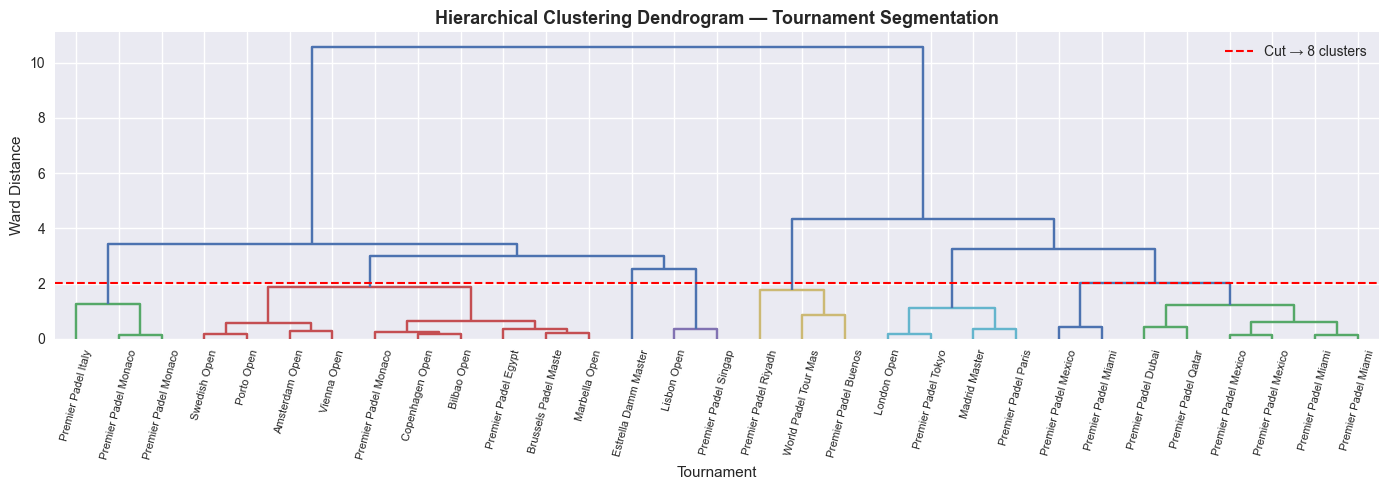

✅ Dendrogram saved


In [12]:
# ============================================================
# 7. DENDROGRAM — HIERARCHICAL VIEW
# ============================================================
fig, ax = plt.subplots(figsize=(14, 5))

Z = linkage(X_scaled, method='ward')
dend = dendrogram(
    Z,
    labels=df['tournament_name'].str[:20].tolist(),
    leaf_rotation=75,
    leaf_font_size=8,
    color_threshold=Z[-OPTIMAL_K+1, 2],
    ax=ax
)
ax.axhline(y=Z[-OPTIMAL_K+1, 2], color='red', linestyle='--',
           linewidth=1.5, label=f'Cut → {OPTIMAL_K} clusters')
ax.set_title('Hierarchical Clustering Dendrogram — Tournament Segmentation',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Tournament')
ax.set_ylabel('Ward Distance')
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/clustering_dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dendrogram saved")

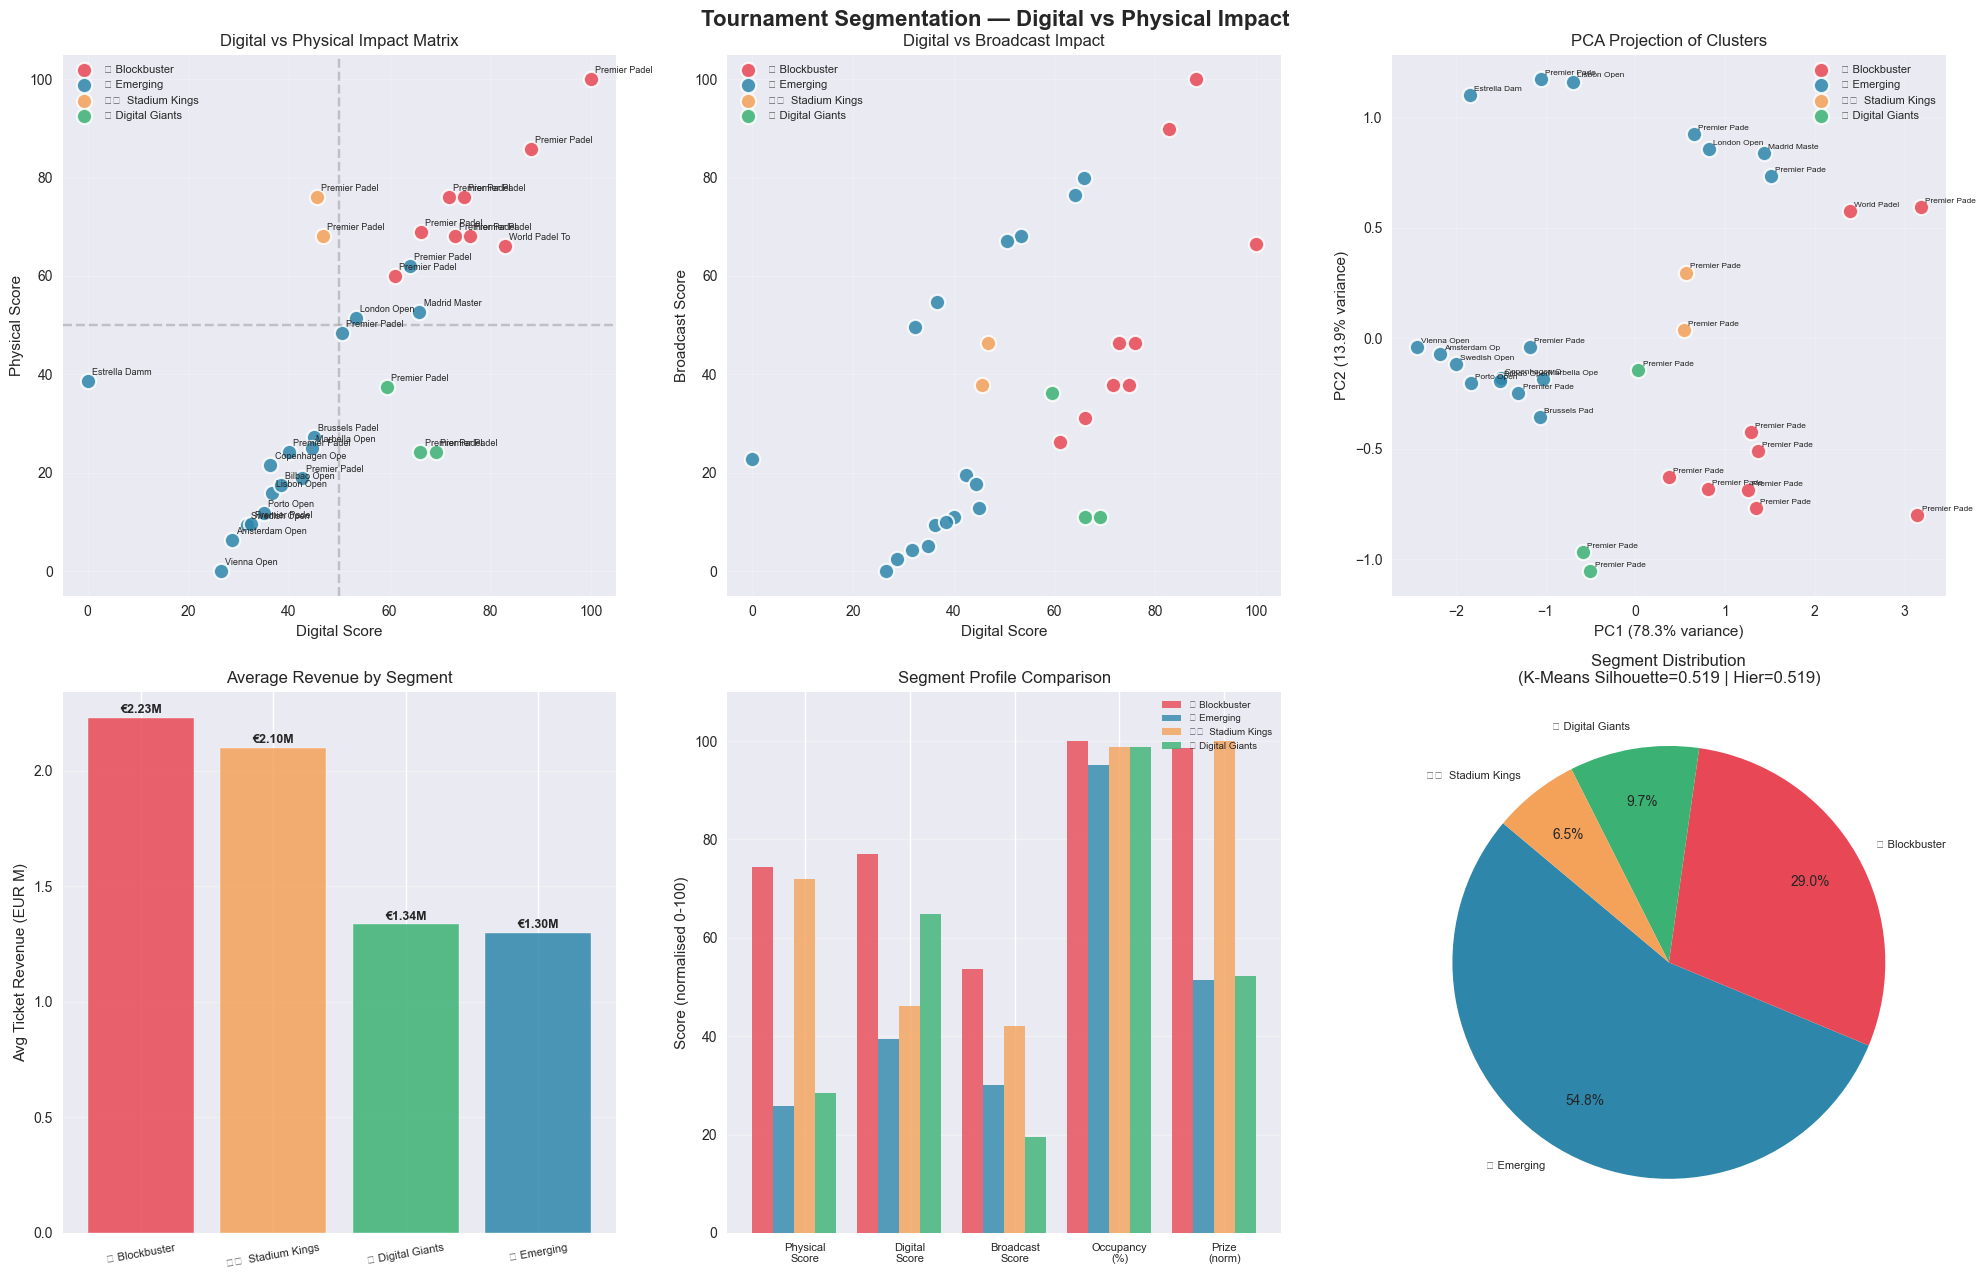

✅ All visualizations saved


In [13]:
# ============================================================
# 8. MAIN VISUALIZATIONS
# ============================================================
palette = {label: c for label, c in zip(
    profile['business_label'].unique(),
    ['#2E86AB', '#E84855', '#3BB273', '#F4A259', '#9B5DE5']
)}

fig, axes = plt.subplots(2, 3, figsize=(20, 13))
fig.suptitle('Tournament Segmentation — Digital vs Physical Impact',
             fontsize=16, fontweight='bold')

# ── 1. Main Scatter: Digital vs Physical ─────────────────
ax = axes[0, 0]
for seg, grp in df.groupby('segment'):
    ax.scatter(grp['digital_score'], grp['physical_score'],
               label=seg, color=palette.get(seg, 'grey'),
               s=120, alpha=0.85, edgecolors='white', linewidth=1.5)
    for _, row in grp.iterrows():
        ax.annotate(row['tournament_name'][:14],
                    (row['digital_score'], row['physical_score']),
                    fontsize=6.5, ha='left', va='bottom',
                    xytext=(3, 3), textcoords='offset points')

ax.axhline(y=50, color='grey', linestyle='--', alpha=0.4)
ax.axvline(x=50, color='grey', linestyle='--', alpha=0.4)
ax.set_xlabel('Digital Score')
ax.set_ylabel('Physical Score')
ax.set_title('Digital vs Physical Impact Matrix')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2)

# ── 2. Broadcast vs Digital ───────────────────────────────
ax = axes[0, 1]
for seg, grp in df.groupby('segment'):
    ax.scatter(grp['digital_score'], grp['broadcast_score'],
               label=seg, color=palette.get(seg, 'grey'),
               s=120, alpha=0.85, edgecolors='white', linewidth=1.5)
ax.set_xlabel('Digital Score')
ax.set_ylabel('Broadcast Score')
ax.set_title('Digital vs Broadcast Impact')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2)

# ── 3. PCA 2D Projection ──────────────────────────────────
ax = axes[0, 2]
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df['pca1'] = X_pca[:, 0]
df['pca2'] = X_pca[:, 1]

for seg, grp in df.groupby('segment'):
    ax.scatter(grp['pca1'], grp['pca2'],
               label=seg, color=palette.get(seg, 'grey'),
               s=120, alpha=0.85, edgecolors='white', linewidth=1.5)
    for _, row in grp.iterrows():
        ax.annotate(row['tournament_name'][:12],
                    (row['pca1'], row['pca2']),
                    fontsize=6, ha='left', xytext=(3, 3),
                    textcoords='offset points')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('PCA Projection of Clusters')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2)

# ── 4. Average Revenue by Segment ────────────────────────
ax = axes[1, 0]
seg_revenue = df.groupby('segment')['ticket_revenue_eur'].mean().sort_values(ascending=False)
bars = ax.bar(range(len(seg_revenue)), seg_revenue.values / 1e6,
              color=[palette.get(s, 'grey') for s in seg_revenue.index],
              alpha=0.85, edgecolor='white')
ax.set_xticks(range(len(seg_revenue)))
ax.set_xticklabels(seg_revenue.index, rotation=10, fontsize=8)
ax.set_ylabel('Avg Ticket Revenue (EUR M)')
ax.set_title('Average Revenue by Segment')
for bar, val in zip(bars, seg_revenue.values / 1e6):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'€{val:.2f}M', ha='center', fontsize=9, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# ── 5. Radar Chart per Cluster ────────────────────────────
ax = axes[1, 1]
categories = ['Physical\nScore', 'Digital\nScore', 'Broadcast\nScore',
              'Occupancy\n(%)', 'Prize\n(norm)']

cluster_radar = df.groupby('segment').agg(
    physical  = ('physical_score',          'mean'),
    digital   = ('digital_score',           'mean'),
    broadcast = ('broadcast_score',         'mean'),
    occupancy = ('occupancy_rate',           'mean'),
    prize     = ('prize_money_eur',          'mean'),
).copy()
cluster_radar['prize'] = cluster_radar['prize'] / cluster_radar['prize'].max() * 100
cluster_radar['occupancy'] = cluster_radar['occupancy'] / cluster_radar['occupancy'].max() * 100

x = np.arange(len(categories))
width = 0.8 / len(cluster_radar)

for i, (seg, row) in enumerate(cluster_radar.iterrows()):
    vals = [row['physical'], row['digital'], row['broadcast'],
            row['occupancy'], row['prize']]
    ax.bar(x + i * width, vals, width,
           label=seg, color=palette.get(seg, 'grey'), alpha=0.8)

ax.set_xticks(x + width * len(cluster_radar) / 2)
ax.set_xticklabels(categories, fontsize=8)
ax.set_ylim(0, 110)
ax.set_title('Segment Profile Comparison')
ax.legend(fontsize=7, loc='upper right')
ax.set_ylabel('Score (normalised 0-100)')
ax.grid(True, alpha=0.3, axis='y')

# ── 6. Segment Size + Silhouette Summary ──────────────────
ax = axes[1, 2]
seg_counts = df['segment'].value_counts()
wedges, texts, autotexts = ax.pie(
    seg_counts.values,
    labels=seg_counts.index,
    autopct='%1.1f%%',
    colors=[palette.get(s, 'grey') for s in seg_counts.index],
    startangle=140,
    pctdistance=0.75
)
for t in texts:
    t.set_fontsize(8)
ax.set_title(f'Segment Distribution\n(K-Means Silhouette={sil_km:.3f} | Hier={sil_hier:.3f})')

plt.tight_layout()
plt.savefig('../outputs/clustering_tournament_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ All visualizations saved")

In [14]:
# ============================================================
# 9. BUSINESS INSIGHTS & EXPORT
# ============================================================
print("""
╔══════════════════════════════════════════════════════════════╗
║           CLUSTERING — BUSINESS INSIGHTS                     ║
╠══════════════════════════════════════════════════════════════╣
║                                                             ║
║  SEGMENT DEFINITIONS:                                       ║
║                                                             ║
║  🌟 BLOCKBUSTER                                             ║
║     → High physical + high digital presence                ║
║     → Top-tier events (Riyadh, Barcelona Finals)           ║
║     → Strategy: Premium sponsorship packages               ║
║       Focus: maintain excellence, expand capacity          ║
║                                                             ║
║  📱 DIGITAL GIANTS                                          ║
║     → Viral online reach but moderate stadium presence     ║
║     → Strategy: Monetise via streaming, brand deals        ║
║       Focus: convert digital fans to ticket buyers         ║
║       Tactic: exclusive live-stream premium tiers          ║
║                                                             ║
║  🏟️  STADIUM KINGS                                          ║
║     → Packed venues, lower digital buzz                    ║
║     → Strategy: Invest in content creation / TikTok        ║
║       Focus: amplify match highlights to grow online       ║
║       Tactic: influencer partnerships during event         ║
║                                                             ║
║  🌱 EMERGING                                                ║
║     → Developing events, growth potential                  ║
║     → Strategy: Double-down on digital first               ║
║       Focus: build audience before expanding venues        ║
║       Tactic: free streaming + social challenges           ║
║                                                             ║
╠══════════════════════════════════════════════════════════════╣
║  MARKETING BUDGET ALLOCATION RECOMMENDATION:                ║
║                                                             ║
║  🌟 Blockbuster  → 40% budget (protect brand equity)       ║
║  📱 Digital Giant → 30% budget (digital-to-physical conv.) ║
║  🏟️  Stadium Kings → 20% budget (content amplification)    ║
║  🌱 Emerging      → 10% budget (test & learn)              ║
╚══════════════════════════════════════════════════════════════╝
""")

# Export enriched dataset
df_export = df[['tournament_name', 'year', 'location',
                'physical_score', 'digital_score', 'broadcast_score',
                'cluster', 'segment',
                'ticket_revenue_eur', 'occupancy_rate',
                'total_viewers_millions', 'prize_money_eur']].copy()

df_export.to_csv('../data/tournaments_clustered.csv', index=False)
print("✅ Enriched dataset saved → ../data/tournaments_clustered.csv")
print(f"\nFinal segment distribution:")
print(df_export['segment'].value_counts().to_string())


╔══════════════════════════════════════════════════════════════╗
║           CLUSTERING — BUSINESS INSIGHTS                     ║
╠══════════════════════════════════════════════════════════════╣
║                                                             ║
║  SEGMENT DEFINITIONS:                                       ║
║                                                             ║
║  🌟 BLOCKBUSTER                                             ║
║     → High physical + high digital presence                ║
║     → Top-tier events (Riyadh, Barcelona Finals)           ║
║     → Strategy: Premium sponsorship packages               ║
║       Focus: maintain excellence, expand capacity          ║
║                                                             ║
║  📱 DIGITAL GIANTS                                          ║
║     → Viral online reach but moderate stadium presence     ║
║     → Strategy: Monetise via streaming, brand deals        ║
║       Focus: convert digital fans to ticke